# 04-2. Checkpoint와 Human-in-the-Loop

- 핵심 기술: LangGraph Checkpoint, `interrupt()`/`Command(resume=...)`,
  Human-in-the-Loop, 재개 시 부작용(Side Effect) 중복 방지
- 최종 산출물: 정보가 부족하면 사람에게 되묻고, 응답을 받아 실행을 이어가는
  문서 점검 Graph

## 1. 학습목표

이 실습을 완료하면 다음을 수행할 수 있다.

1. Checkpoint가 무엇을 저장하고 왜 필요한지 설명할 수 있다.
2. `interrupt()`로 Graph 실행을 멈추고, `Command(resume=...)`로 같은
   `thread_id`에서 실행을 이어갈 수 있다.
3. 재개(resume) 시 Node가 처음부터 다시 실행된다는 점을 설명하고, 이로 인해
   부작용(알림 전송 등)이 중복 실행될 수 있음을 확인할 수 있다.
4. State 내부가 아니라 State 밖의 저장소를 이용해 부작용을 멱등(Idempotent)하게
   만들 수 있다.

## 2. 문제 상황

Agent가 문서를 점검하다가 "이 문서가 내부용인지 외부 고객용인지" 같은, 스스로 판단할 수 없는 정보를 만나면 어떻게 해야 할까?  
임의로 추측해서 진행하면 잘못된 결과를 낼 위험이 있다.  
그렇다고 처음부터 사람이 모든 값을 미리 입력해 두는 것도 비현실적이다.  
이럴 때는 실행을 사람의 응답을 기다리는 지점에서 멈추고, 응답을 받으면 그 지점부터 이어서 실행해야 한다.  

**실습 시나리오**

```text
사용자: 이 문서를 점검해줘.
Agent: 이 문서가 내부용인지 외부 고객용인지 확인이 필요합니다.
사용자: 외부 고객에게 제공하는 문서입니다.
Agent: 추가된 정보를 반영하여 점검을 재개합니다.
```

이 Notebook은 이 시나리오를 LangGraph의 `interrupt()`/`Command(resume=...)`로 구현하고,  
재개 시 Node가 처음부터 다시 실행되면서 발생하는 부작용 중복 문제와 그 해결 방법을 다룬다.   

## 3. 핵심 개념

### 3.1 정의

Checkpoint는 Graph 실행 중 특정 시점의 State를 저장해 두어, 나중에 그 지점부터 실행을 이어갈 수 있게 하는 기록이다.  
Human-in-the-Loop(HITL)은 Graph가 스스로 판단할 수 없는 지점에서 실행을 의도적으로 멈추고 (`interrupt()`),   
사람이 응답하면 그 지점부터 다시 이어가는(`Command(resume=...)`)  패턴이다.

### 3.2 개념이 필요한 이유

Checkpoint가 없으면 사람의 응답을 기다리는 동안 실행 상태를 어디에도 보관할 수 없어,   
응답을 받은 뒤 처음부터 다시 실행해야 한다.  
문서가 길거나 이미 비용이 드는 작업(LLM 호출, 외부 API 호출)을 거쳤다면 이를 반복하는 것은 비효율적이며,   
이미 완료된 단계의 결과가 응답을 기다리는 동안 달라질 수도 있다.    
Checkpoint는 "어디까지 실행했는지"를 보존해서 이 문제를 없앤다.

### 3.3 주요 구성요소

| 구성요소 | 역할 |
|---|---|
| `MemorySaver` | Checkpoint를 메모리에 저장하는 Checkpointer |
| `thread_id` | 하나의 대화/작업 흐름을 식별하는 키. `config={"configurable": {"thread_id": ...}}`로 전달 |
| `interrupt(value)` | Graph 실행을 멈추고 `value`를 사람에게 전달할 질문/payload로 반환 |
| `Command(resume=value)` | 멈춘 지점부터 `value`를 응답으로 주고 실행을 재개 |
| `DocumentCheckState` | 문서 점검 Graph의 State Schema |

### 3.4 동작 과정
```mermaid
flowchart TD
    A[입력 분석] --> B[필수 정보 확인]
    B -- 충분함 --> C[다음 단계]
    B -- 부족함 --> D["추가 질문 → Interrupt"]
    D --> E[사용자 응답]
    E --> F[Resume]
    F --> G[다음 단계]
```



### 3.5 코드와 개념의 대응 관계

| 코드 요소 | 구현 개념 |
|---|---|
| `builder.compile(checkpointer=MemorySaver())` | Checkpoint 저장소를 Graph에 연결 |
| `config={"configurable": {"thread_id": ...}}` | 어떤 실행 흐름의 Checkpoint를 쓸지 지정 |
| `interrupt({...})` | 사람에게 물어볼 질문을 담아 실행을 멈춤 |
| `result["__interrupt__"]` | 멈췄을 때 반환되는 질문/payload |
| `Command(resume=answer)` | 사람의 응답으로 실행을 재개 |

### 3.6 유사 개념과의 차이

Checkpoint와 (Notebook 04-1의) Memory는 둘 다 "무언가를 저장해 둔다"는 점에서
비슷해 보이지만 목적이 다르다.

| 항목 | Checkpoint | Memory |
|---|---|---|
| 목적 | 실행 상태 복구 | 이후 판단에 활용할 정보 축적 |
| 저장 대상 | 현재 Graph State | 사용자·작업 관련 정보 |
| 활용 | 중단 후 재개 | 이후 판단에 참조 |
| 대표 식별자 | `thread_id` | 사용자 또는 Memory Namespace |

### 3.7 사용 시점과 적용 조건

Graph가 스스로 결정할 수 없는 정보(사람의 확인, 승인, 추가 입력)가 필요한
지점에서 `interrupt()`를 사용한다. 단순히 값이 비어 있다고 무조건 멈추는
것이 아니라, "이 정보 없이는 다음 단계를 안전하게 진행할 수 없는가"를
기준으로 판단해야 한다.

### 3.8 한계와 주의사항

`interrupt()`가 호출된 Node는 `Command(resume=...)`로 재개할 때 **처음부터
다시 실행**된다. `interrupt()` 호출 이전에 있던 코드(예: 알림 전송)도 함께
다시 실행되므로, 외부에 영향을 주는 부작용은 반드시 멱등하게 만들어야 한다.
State에 "이미 처리했다"는 플래그를 저장해 두는 방법은 통하지 않는데, 멈춘
시점에 저장되는 Checkpoint는 Node가 실행을 **시작하기 이전**의 State이기
때문이다. State 내부의 변경은 재개 시 그대로 사라진다.

### 3.9 자주 발생하는 오해

"State에 `notified = True` 같은 플래그를 하나 추가해 두면 중복 실행을 막을
수 있다"는 오해가 흔하다. 실제로는 Checkpoint가 Node 실행 이전 시점의
State를 저장하기 때문에, Node 안에서 State를 바꿔도 재개 시 그 변경은
반영되지 않는다. 부작용을 막으려면 Graph의 State/Checkpoint 밖에 있는
별도 저장소(예: 모듈 전역 집합)를 `thread_id` 기준으로 확인해야 한다.

### 3.10 핵심 정리

- Checkpoint는 Graph 실행 상태를 저장해 중단 후 재개를 가능하게 한다.
- `interrupt()`는 실행을 멈추고 질문을 반환하며, `Command(resume=...)`는
  같은 `thread_id`에서 응답을 주고 재개한다.
- 재개 시 Node는 처음부터 다시 실행되므로, `interrupt()` 이전의 부작용은
  중복 실행될 수 있다.
- 부작용을 막으려면 State가 아니라 State 밖의 저장소를 `thread_id`로
  확인해야 한다.

## 4. 실행 구조
```text
review_app.invoke(state, config={"thread_id": T})
        │
        ▼
   analyze_input ──▶ route_after_check ──▶ 충분함? ──▶ finalize ──▶ END
        │                                     │
        │                                    아니오
        │                                     ▼
        │                              ask_more_info
        │                                     │
        │                            interrupt(question)
        │                                     │
        │                         MemorySaver에 Checkpoint 저장
        │                                     │
        │                    ◀── 실행 중단, __interrupt__ 반환
        │
review_app.invoke(Command(resume=answer), config={"thread_id": T})
        │
        ▼
  Checkpoint에서 ask_more_info부터 재개 ──▶ finalize ──▶ END
```

## 5. 환경 설정

반복되는 경로 탐색과 모델 생성 코드는 `src/agentic_ai` 공통 모듈에서 관리한다.
아래 셀에서는 이 Notebook에 필요한 표준 라이브러리와 공통 기능만 불러온다.

> 처음 실행하거나 환경 오류가 발생하면 프로젝트 루트의
> `00_environment_check.ipynb`를 먼저 실행한다.


In [16]:
import json
from typing import TypedDict

from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

from agentic_ai.logging_utils import save_log
from agentic_ai.notebook_utils import print_environment_summary, show_graph
from agentic_ai.paths import OUTPUT_DIR

print_environment_summary()
print("- 이 실습은 Chat 모델 없이 Graph 제어 흐름만 사용합니다.")


[환경 설정 확인]
- 프로젝트: E:\agentic_ai_lab
- 데이터: E:\agentic_ai_lab\data
- 출력: E:\agentic_ai_lab\outputs
- 이 실습은 Chat 모델 없이 Graph 제어 흐름만 사용합니다.


## 6. 최소 실행 예제

`interrupt()`와 `Command(resume=...)`의 가장 단순한 형태를 먼저 확인한다.

In [17]:
class MiniState(TypedDict):
    answer: str


def ask_node(state: MiniState) -> dict:
    # interrupt는 값을 즉시 반환하지 않고 현재 실행을 중단해 질문 정보를 호출자에게 보낸다.
    reply = interrupt("좋아하는 색은 무엇인가요?")
    return {"answer": reply}


mini_builder = StateGraph(MiniState)
mini_builder.add_node("ask", ask_node)
mini_builder.add_edge(START, "ask")
mini_builder.add_edge("ask", END)
# 중단 지점의 State를 저장하려면 Graph를 Checkpointer와 함께 compile해야 한다.
mini_app = mini_builder.compile(checkpointer=MemorySaver())

mini_config = {"configurable": {"thread_id": "mini-1"}}
first = mini_app.invoke({"answer": ""}, config=mini_config)
print("첫 번째 invoke:", first)

# 재개할 때도 같은 thread_id를 사용해야 저장된 중단 지점을 찾을 수 있다.
second = mini_app.invoke(Command(resume="파란색"), config=mini_config)
print("재개 후:", second)

assert "__interrupt__" in first
assert first["__interrupt__"][0].value == "좋아하는 색은 무엇인가요?"
assert second == {"answer": "파란색"}

첫 번째 invoke: {'answer': '', '__interrupt__': [Interrupt(value='좋아하는 색은 무엇인가요?', id='08565d60e567aca86e0e2e5d8efa2b31')]}
재개 후: {'answer': '파란색'}


## 7. 단계별 구현

### 7.1 State와 기본 Node

`DocumentCheckState`는 문서 텍스트, 대상 독자(`audience`), 최종 결과를 담는다.   
`thread_id`는 State가 아니라 Node의 두 번째 인자인 `config`를 통해 전달받는다.  

In [18]:
class DocumentCheckState(TypedDict):
    document_text: str
    audience: str
    result: str


def analyze_input_node(state: DocumentCheckState) -> dict:
    print(f"[분석] 문서 길이: {len(state['document_text'])}자")
    # State를 바꿀 필요가 없는 Node는 빈 update를 반환할 수 있다.
    return {}


def finalize_node(state: DocumentCheckState) -> dict:
    summary = f"[{state['audience']}] 문서 점검이 완료되었습니다."
    return {"result": summary}

### 7.2 분기 조건

**TODO**:   
`route_after_check()`를 작성한다.  
- `state["audience"]`에 값이 있으면(참으로 평가되면) `"sufficient"`를 반환한다.  
- 값이 없으면(빈 문자열 등) `"ask_more_info"`를 반환한다.  

In [19]:
def route_after_check(state: DocumentCheckState) -> str:
    """audience가 채워져 있으면 충분, 비어 있으면 추가 질문이 필요하다."""
    # 반환 키는 add_conditional_edges의 path map과 정확히 일치해야 한다.
    return "sufficient" if state.get("audience") else "ask_more_info"


assert route_after_check({"document_text": "x", "audience": "", "result": ""}) == "ask_more_info"
assert route_after_check({"document_text": "x", "audience": "외부 고객", "result": ""}) == "sufficient"
print("route_after_check 동작 확인 완료")

route_after_check 동작 확인 완료


### 7.3 추가 질문 Node (아직 부작용 문제를 고려하지 않은 버전)

`ask_more_info_node`는 검토자에게 알림을 보낸 뒤 `interrupt()`로 사용자 응답을 기다린다.  
이 버전은 아직 재개 시 알림이 중복 전송되는 문제를 고려하지 않은 상태다.  

In [20]:
NOTIFY_CALL_COUNT = 0

def notify_reviewer(state: DocumentCheckState) -> None:
    global NOTIFY_CALL_COUNT
    NOTIFY_CALL_COUNT += 1
    print(f"[알림] 검토자에게 확인 요청을 전송했습니다. (총 {NOTIFY_CALL_COUNT}회)")


def ask_more_info_node(state: DocumentCheckState) -> dict:
    # 재개 시 Node가 처음부터 다시 실행되므로 interrupt 앞의 알림도 다시 호출된다.
    notify_reviewer(state)
    answer = interrupt({"question": "이 문서가 내부용인지 외부 고객용인지 확인이 필요합니다."})
    return {"audience": answer}

### 7.4 Graph 구성과 정상 경로 확인

먼저 `audience`가 이미 채워진 입력으로 `interrupt` 없이 바로 끝까지
실행되는 경로를 확인한다.

In [21]:
review_builder = StateGraph(DocumentCheckState)
review_builder.add_node("analyze_input", analyze_input_node)
review_builder.add_node("ask_more_info", ask_more_info_node)
review_builder.add_node("finalize", finalize_node)
review_builder.add_edge(START, "analyze_input")
review_builder.add_conditional_edges(
    "analyze_input",
    route_after_check,
    {"sufficient": "finalize", "ask_more_info": "ask_more_info"},
)
review_builder.add_edge("ask_more_info", "finalize")
review_builder.add_edge("finalize", END)
# thread별 Checkpoint가 interrupt 전 State와 재개 위치를 보관한다.
review_app = review_builder.compile(checkpointer=MemorySaver())


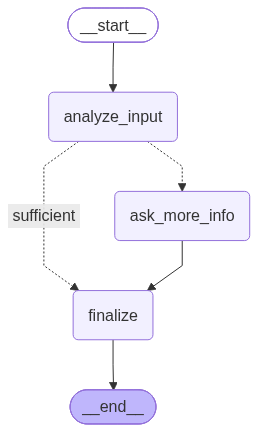

In [22]:
# 시각화는 네트워크 환경에 따라 실패할 수 있으므로 선택적으로 실행한다.
show_graph(review_app)

In [23]:
review_config_1 = {"configurable": {"thread_id": "review-ok"}}
direct_result = review_app.invoke(
    {"document_text": "이 문서를 점검해줘.", "audience": "외부 고객", "result": ""},
    config=review_config_1,
)
print(direct_result)
assert direct_result["result"] == "[외부 고객] 문서 점검이 완료되었습니다."

[분석] 문서 길이: 11자
{'document_text': '이 문서를 점검해줘.', 'audience': '외부 고객', 'result': '[외부 고객] 문서 점검이 완료되었습니다.'}


### 7.5 등록되지 않은 thread_id로 재개하면 어떻게 되는가

Checkpoint가 없는 `thread_id`로 `Command(resume=...)`를 호출하면 이어갈 실행 상태 자체가 없다.   
이 경우 LangGraph는 재개를 거부하는 대신 `START`부터 빈 State(`{}`)로 새로 실행을 시작하는데,  
`analyze_input_node`가 `state["document_text"]`에 바로 접근하므로 필수 필드가 없어 오류가 발생한다.  

In [24]:
# 저장된 Checkpoint가 없는 thread_id는 Command만으로 재개할 수 없다.
try:
    review_app.invoke(Command(resume="아무개"), config={"configurable": {"thread_id": "not-registered"}})
    raised = False
except (ValueError, KeyError):
    raised = True

assert raised is True
print("등록되지 않은 thread_id로 재개하면 오류가 발생한다:", raised)

등록되지 않은 thread_id로 재개하면 오류가 발생한다: True


## 8. 실행 결과 관찰

`audience`가 비어 있는 입력으로 실행하면 `ask_more_info` Node에서
`interrupt()`가 발생해 실행이 멈춘다.

In [25]:
NOTIFY_CALL_COUNT = 0
review_config_2 = {"configurable": {"thread_id": "review-001"}}
paused = review_app.invoke(
    {"document_text": "이 문서를 점검해줘.", "audience": "", "result": ""},
    config=review_config_2,
)
print(paused)

# 중단 결과의 __interrupt__에는 사용자에게 표시할 질문 payload가 들어 있다.
assert "__interrupt__" in paused
assert paused["__interrupt__"][0].value == {"question": "이 문서가 내부용인지 외부 고객용인지 확인이 필요합니다."}
assert NOTIFY_CALL_COUNT == 1

[분석] 문서 길이: 11자
[알림] 검토자에게 확인 요청을 전송했습니다. (총 1회)
{'document_text': '이 문서를 점검해줘.', 'audience': '', 'result': '', '__interrupt__': [Interrupt(value={'question': '이 문서가 내부용인지 외부 고객용인지 확인이 필요합니다.'}, id='4f8acf39bdef6b7b3941be8d70ebfcbb')]}


**결과 해석**: `paused["__interrupt__"]`에 담긴 질문은 실습 시나리오의   
"이 문서가 내부용인지 외부 고객용인지 확인이 필요합니다."와 정확히 일치한다.  
이 시점에서 Graph는 `review-001` Checkpoint에 `ask_more_info` Node 직전 상태를 저장해 두고 실행을 멈춘다.  

## 9. 실패 실험: 재개 시 알림이 중복 전송됨

사용자는 질문에 한 번만 답했다. 그런데 `Command(resume=...)`로 재개하면
어떤 일이 벌어지는지 확인한다.

In [26]:
before_resume_count = NOTIFY_CALL_COUNT
# Command(resume=...) 값은 같은 thread의 interrupt 호출 결과로 전달된다.
resumed = review_app.invoke(Command(resume="외부 고객"), config=review_config_2)
print(resumed)
print(f"재개 전 알림 횟수: {before_resume_count}, 재개 후 알림 횟수: {NOTIFY_CALL_COUNT}")

assert resumed["result"] == "[외부 고객] 문서 점검이 완료되었습니다."
assert NOTIFY_CALL_COUNT == before_resume_count + 1

[알림] 검토자에게 확인 요청을 전송했습니다. (총 2회)
{'document_text': '이 문서를 점검해줘.', 'audience': '외부 고객', 'result': '[외부 고객] 문서 점검이 완료되었습니다.'}
재개 전 알림 횟수: 1, 재개 후 알림 횟수: 2


**원인 분석 질문**

- 사용자는 질문에 딱 한 번 답했는데, 왜 `notify_reviewer()`는 두 번 호출되었는가?  
- `Command(resume=...)`로 재개했을 때 `ask_more_info_node`는 어디서부터 다시 실행되는가?  
- State에 `notified = True` 같은 플래그를 저장해 두면 이 문제를 막을 수 있는가?  
  Checkpoint에 저장되는 State가 Node 실행 "이전" 시점 기준이라는 점과 연결지어 생각해 보자.  
- 이 알림이 실제로 이메일이나 Slack 메시지를 보내는 코드였다면 어떤 문제가 발생하는가?  

## 10. 오류 수정 실습

State 안이 아니라 State 밖에 있는 저장소(`NOTIFIED_THREADS`)를
`thread_id` 기준으로 확인하면, 재개로 인한 재실행에서도 중복 알림을 막을
수 있다.

**TODO**: `notify_reviewer_once()`를 작성한다.

- `config["configurable"]["thread_id"]`로 현재 실행의 `thread_id`를
  가져온다.
- 이미 `NOTIFIED_THREADS`에 있는 `thread_id`면 알림을 보내지 않고
  `False`를 반환한다.
- 아직 없다면 `NOTIFIED_THREADS`에 추가하고, 알림 횟수를 늘린 뒤 `True`를
  반환한다.

In [27]:
NOTIFIED_THREADS: set[str] = set()
NOTIFY_CALL_COUNT_FIXED = 0


def notify_reviewer_once(state: DocumentCheckState, config: RunnableConfig) -> bool:
    """같은 thread_id에는 실행이 재개되어도 알림을 한 번만 보낸다."""
    global NOTIFY_CALL_COUNT_FIXED
    thread_id = config["configurable"]["thread_id"]
    # 외부 알림 같은 부작용은 thread_id 기준 멱등성 키로 중복 실행을 막는다.
    if thread_id in NOTIFIED_THREADS:
        return False
    NOTIFIED_THREADS.add(thread_id)
    NOTIFY_CALL_COUNT_FIXED += 1
    print(f"[알림-수정판] 검토자에게 확인 요청을 전송했습니다. (총 {NOTIFY_CALL_COUNT_FIXED}회)")
    return True


demo_config_a = {"configurable": {"thread_id": "notify-demo"}}
assert notify_reviewer_once({}, demo_config_a) is True
assert notify_reviewer_once({}, demo_config_a) is False
assert NOTIFY_CALL_COUNT_FIXED == 1
print("notify_reviewer_once 동작 확인 완료")

[알림-수정판] 검토자에게 확인 요청을 전송했습니다. (총 1회)
notify_reviewer_once 동작 확인 완료


**수정 결과 재검증**: 수정된 `ask_more_info_node_fixed`로 새 Graph를 만들고,
interrupt와 resume을 모두 거친 뒤에도 알림이 한 번만 전송되었는지 확인한다.

In [28]:
NOTIFIED_THREADS.clear()
NOTIFY_CALL_COUNT_FIXED = 0


def ask_more_info_node_fixed(state: DocumentCheckState, config: RunnableConfig) -> dict:
    # LangGraph가 주입한 config에서 thread_id를 읽어 재실행에도 같은 알림 키를 사용한다.
    notify_reviewer_once(state, config)
    answer = interrupt({"question": "이 문서가 내부용인지 외부 고객용인지 확인이 필요합니다."})
    return {"audience": answer}


fixed_builder = StateGraph(DocumentCheckState)
fixed_builder.add_node("analyze_input", analyze_input_node)
fixed_builder.add_node("ask_more_info", ask_more_info_node_fixed)
fixed_builder.add_node("finalize", finalize_node)
fixed_builder.add_edge(START, "analyze_input")
fixed_builder.add_conditional_edges(
    "analyze_input",
    route_after_check,
    {"sufficient": "finalize", "ask_more_info": "ask_more_info"},
)
fixed_builder.add_edge("ask_more_info", "finalize")
fixed_builder.add_edge("finalize", END)
review_app_fixed = fixed_builder.compile(checkpointer=MemorySaver())

fixed_config = {"configurable": {"thread_id": "review-002"}}
paused_fixed = review_app_fixed.invoke(
    {"document_text": "이 문서를 점검해줘.", "audience": "", "result": ""},
    config=fixed_config,
)
assert "__interrupt__" in paused_fixed
count_after_pause = NOTIFY_CALL_COUNT_FIXED

resumed_fixed = review_app_fixed.invoke(Command(resume="외부 고객"), config=fixed_config)
print(resumed_fixed)

assert resumed_fixed["result"] == "[외부 고객] 문서 점검이 완료되었습니다."
assert NOTIFY_CALL_COUNT_FIXED == count_after_pause
print(f"재검증 통과: 재개 후에도 알림 횟수는 {NOTIFY_CALL_COUNT_FIXED}회로 유지됨")

[분석] 문서 길이: 11자
[알림-수정판] 검토자에게 확인 요청을 전송했습니다. (총 1회)
{'document_text': '이 문서를 점검해줘.', 'audience': '외부 고객', 'result': '[외부 고객] 문서 점검이 완료되었습니다.'}
재검증 통과: 재개 후에도 알림 횟수는 1회로 유지됨


## 11. 도전 과제

1. `audience`뿐 아니라 `document_text`도 비어 있을 수 있다고 가정하고,
   `interrupt()` payload에 부족한 필드 목록을 구조화해서 담아본다.
2. 사용자가 재개 시 빈 문자열처럼 유효하지 않은 값을 보내면, `finalize`로
   넘어가지 않고 다시 `interrupt()`를 발생시켜 재질문하도록 만들어본다.
3. `NOTIFIED_THREADS`를 Notebook 04-1의 가상 시계(`CURRENT_TICK`)처럼 일정
   시간이 지나면 초기화하는 만료 로직을 추가해본다.

## 12. 테스트

**테스트 유형: 로컬 Graph 통합 테스트 — 결정적, 외부 API 호출 없음**

Checkpoint, `interrupt()`/`Command(resume=...)`와 부작용 중복 방지 경로를 검증한다.

In [29]:
assert route_after_check({"document_text": "x", "audience": "", "result": ""}) == "ask_more_info"
assert route_after_check({"document_text": "x", "audience": "외부", "result": ""}) == "sufficient"

assert direct_result["result"] == "[외부 고객] 문서 점검이 완료되었습니다."

assert "__interrupt__" in paused
assert paused["__interrupt__"][0].value == {"question": "이 문서가 내부용인지 외부 고객용인지 확인이 필요합니다."}

assert resumed["result"] == "[외부 고객] 문서 점검이 완료되었습니다."
assert NOTIFY_CALL_COUNT == 2

assert NOTIFY_CALL_COUNT_FIXED == count_after_pause
assert resumed_fixed["result"] == "[외부 고객] 문서 점검이 완료되었습니다."

try:
    review_app.invoke(Command(resume="x"), config={"configurable": {"thread_id": "still-not-registered"}})
    assert False, "오류가 발생해야 한다"
except (ValueError, KeyError):
    pass

document_check_fields = {"document_text", "audience", "result"}
assert set(DocumentCheckState.__annotations__.keys()) == document_check_fields

print("테스트 통과")

테스트 통과


## 13. 결과 저장

In [30]:
checkpoint_hitl_log = {
    "mini_demo": {
        "first_interrupt_value": first["__interrupt__"][0].value,
        "second": second,
    },
    "review_naive": {
        "thread_id": "review-001",
        "notify_call_count": NOTIFY_CALL_COUNT,
        "final_result": resumed["result"],
    },
    "review_fixed": {
        "thread_id": "review-002",
        "notify_call_count_fixed": NOTIFY_CALL_COUNT_FIXED,
        "final_result": resumed_fixed["result"],
    },
}
saved_path = save_log(checkpoint_hitl_log, OUTPUT_DIR / "logs" / "04-2_checkpoint_hitl_log.json")
print("로그 저장 위치:", saved_path)

state_snapshot = review_app.get_state(review_config_2)
checkpoint_snapshot = {
    "thread_id": "review-001",
    "state": state_snapshot.values,
    "next_nodes": list(state_snapshot.next),
}
checkpoint_path = OUTPUT_DIR / "checkpoints" / "review-001_checkpoint.json"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
with checkpoint_path.open("w", encoding="utf-8") as f:
    json.dump(checkpoint_snapshot, f, ensure_ascii=False, indent=2)
print("체크포인트 스냅샷 저장 위치:", checkpoint_path)

로그 저장 위치: E:\agentic_ai_lab\outputs\logs\04-2_checkpoint_hitl_log.json
체크포인트 스냅샷 저장 위치: E:\agentic_ai_lab\outputs\checkpoints\review-001_checkpoint.json


## 14. 핵심 정리

- Checkpoint는 Graph 실행 중 특정 시점의 State를 저장해 중단 후 재개를 가능하게 한다.   
- `interrupt()`는 실행을 멈추고 질문을 반환하며, `Command(resume=...)`는 같은 `thread_id`에서 응답을 주고 재개한다.  
- 재개 시 Node는 처음부터 다시 실행되므로, `interrupt()` 이전에 있는 부작용(알림 전송 등)은 그대로 중복 실행될 수 있다.  
- State 안의 플래그만으로는 `interrupt()` 이전 부작용의 중복 실행을 막기 어렵다.   
  Checkpoint는 Node 실행 이전 시점의 State만 저장하기 때문이다.  
  부작용을 막으려면 State 밖의 저장소를 `thread_id` 기준으로 확인해야 한다.  
- 이 실습의 `MemorySaver`와 Python `set`은 한 프로세스 안에서만 유지된다.  
  운영 환경에서는 영속 Checkpointer와 원자적 멱등성 키 저장소를 사용해야 한다.   


## 15. 확인 문제

1. Checkpoint는 정확히 어떤 시점의 State를 저장하는가?
2. `Command(resume=...)`로 재개했을 때, `interrupt()`를 호출한 Node는
   어디서부터 다시 실행되는가?
3. State 안에 "이미 알림을 보냈다"는 플래그를 저장해 두는 방식이 왜
   재개 시 중복 알림을 막지 못하는가?
4. Checkpoint와 Memory(Notebook 04-1)는 둘 다 "저장"이라는 점에서
   비슷해 보이지만 목적이 다르다. 어떻게 다른가?